In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


heart = pd.read_csv("C:\\Users\\Farhad\\Data-Mining-Tasks\\data\\heart.csv")

## Question 1
**Based on the analysis in the previous step:**

**Which columns were most relevant to the target(Extract a list of them)?**

The most positive correlation with the target field is formed by `cp`, `thalach` and `slope`, and the most negative correlation is formed by `exang`, `oldpeak` and `ca` with the target field.

## Question 2
**Create a table:**

**`Feature` ,`Business Importance`, `Data Importance`**

In [37]:
feature_importance = pd.DataFrame({
    "Feature": [
        "age", "sex", "cp", "trestbps", "chol",
        "fbs", "restecg", "thalach", "exang",
        "oldpeak", "slope", "ca", "thal"
    ],
    "Business Importance": [
        "High", "Medium", "High", "High", "High",
        "Medium", "Medium", "High", "High",
        "High", "High", "High", "High"
    ],
    "Data Importance": [
        "Medium", "Medium", "High", "Low", "Low",
        "Low", "Low", "High", "High",
        "High", "High", "High", "High"
    ]
})

feature_importance

,Feature,Business Importance,Data Importance
0,age,High,Medium
1,sex,Medium,Medium
2,cp,High,High
3,trestbps,High,Low
4,chol,High,Low
5,fbs,Medium,Low
6,restecg,Medium,Low
7,thalach,High,High
8,exang,High,High
9,oldpeak,High,High


## Question 3
**Select at least three features that you think might not be useful for modeling.**

**Write down your reasons.**

According to the heatmap plot and the information collected in my previous question, I personally think that the `sex`, `fbs`, and `restecg` fields can be removed because they have a weak relationship with the target field and their importance in the medical world is less than other fields.

## Question 4
**Create a new version of the dataset that contains only the features you selected.**

**Name:** selected_df



In [38]:
selected_df = heart[[
    "cp",
    "thalach",
    "exang",  
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]]

selected_df

,cp,thalach,exang,oldpeak,slope,ca,thal,target
0,3,150,0,2.3,0,0,1,1
1,2,187,0,3.5,0,0,2,1
2,1,172,0,1.4,2,0,2,1
3,1,178,0,0.8,2,0,2,1
4,0,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...
298,0,123,1,0.2,1,0,3,0
299,3,132,0,1.2,1,0,3,0
300,0,141,0,3.4,1,2,3,0
301,0,115,1,1.2,1,1,3,0


## Question 5
**Compare the number of features before and after selection.**

By reducing the sizes of the two data frames, we arrive at the number 1818, which is approximately 42.85% of our dataset. It has become more compact because I removed 6 columns or features, but this does not mean that the records have been deleted.

In [39]:
from IPython.display import display

display(selected_df.shape, selected_df.size)
display(heart.shape, heart.size)

(303, 8)

2424

(303, 14)

4242

## Question 6
**Recheck all Null values.**

We don't have null data in this dataset.

In [40]:
selected_df.isnull().sum()

cp         0
thalach    0
exang      0
oldpeak    0
slope      0
ca         0
thal       0
target     0
dtype: int64

## Question 7
**For each column, specify:**

- **Number of Nulls:** 0
- **Percentage of Nulls:** 0.0%

## Question 8
**If there is missing data, Suggest three different ways to fill it in.**

- Missing qualitative data can be replaced using the random forest algorithm.

- Both numerical and qualitative data can be quantified using mean/median/mode. This method uses statistical criteria to impute missing values.

- Missing value prediction can be very effective if designed properly. The idea behind this method is that we predict the missing input value with the help of other features of the dataset. The most common prediction algorithms for computing are linear regression and nearest neighbor (KNN).

## Question 9
**Choose one of the methods and implement it.**

Since we do not have missing data, we cannot implement any of these methods.

## Question 10
**Identify duplicate records.**

Based on this result, we find that in the original dataset we only have one duplicate record, but in the selected dataset we have 9 duplicate records, 8 of which are incorrect.

In [41]:
display(heart[heart.duplicated()])
display(selected_df[selected_df.duplicated()])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


,cp,thalach,exang,oldpeak,slope,ca,thal,target
54,2,172,0,0.0,2,0,2,1
81,1,170,0,0.0,2,0,2,1
87,1,156,0,0.0,2,0,3,1
88,2,158,0,1.6,1,0,2,1
115,2,170,0,0.0,2,0,2,1
124,2,179,0,0.0,2,0,2,1
135,0,163,0,0.0,2,0,2,1
156,2,179,0,0.0,2,0,2,1
164,2,173,0,0.0,2,4,2,1


## Question 11
**Create a copy of the data without duplicate records.**

In [42]:
unique_dataset = heart.drop(index=164)
display(unique_dataset[unique_dataset.duplicated()])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


## Question 12
**Using Boxplot and IQR to find the outliers of each numeric feature.**



age: 0
sex: 0
cp: 0
trestbps: 9
chol: 5
fbs: 45
restecg: 0
thalach: 1
exang: 0
oldpeak: 5
slope: 0
ca: 25
thal: 2


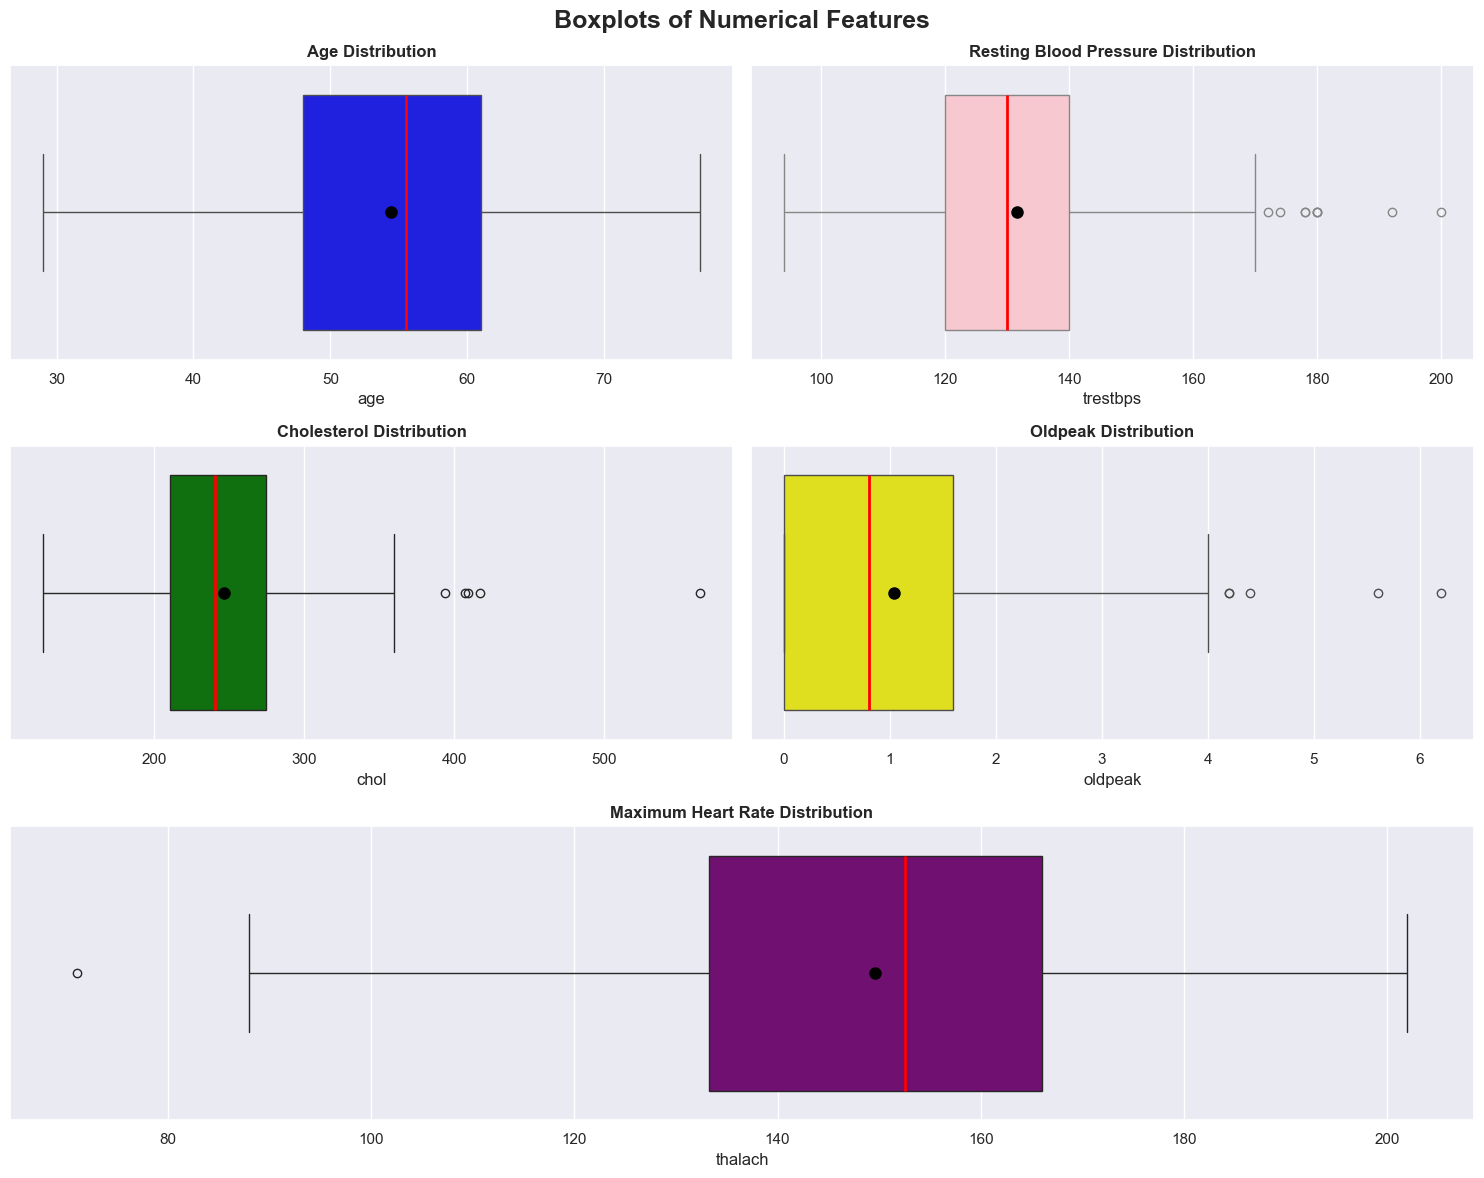

In [43]:
numerical_features = ["age", "sex",	"cp", "trestbps",
                      "chol", "fbs", "restecg", "thalach",
                      "exang", "oldpeak", "slope", "ca", "thal"
                      ]

for column in numerical_features:
    Q1 = heart[column].describe()["25%"]
    Q3 = heart[column].describe()["75%"]
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = heart[
        (heart[column] < lower_bound) |
        (heart[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)}")

sns.set_theme(style="darkgrid")

fig = plt.figure(figsize=(15, 12))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 1]
)

fig.suptitle(
    "Boxplots of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

median_props = {
    "color": "red",
    "linewidth": 2
}

mean_props = {
    "marker": "o",
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "markersize": 8
}

ax1 = plt.subplot(gs[0, 0])
sns.boxplot(
    x=unique_dataset["age"],
    ax=ax1,
    color="blue",
    showmeans=True,
    medianprops=median_props,
    meanprops=mean_props
)
ax1.set_title("Age Distribution", fontweight="bold")


ax2 = plt.subplot(gs[0, 1])
sns.boxplot(
    x=unique_dataset["trestbps"],
    ax=ax2,
    color="pink",
    showmeans=True,
    medianprops=median_props,
    meanprops=mean_props
)
ax2.set_title("Resting Blood Pressure Distribution", fontweight="bold")


ax3 = plt.subplot(gs[1, 0])
sns.boxplot(
    x=unique_dataset["chol"],
    ax=ax3,
    color="green",
    showmeans=True,
    medianprops=median_props,
    meanprops=mean_props
)
ax3.set_title("Cholesterol Distribution", fontweight="bold")


ax4 = plt.subplot(gs[1, 1])
sns.boxplot(
    x=unique_dataset["oldpeak"],
    ax=ax4,
    color="yellow",
    showmeans=True,
    medianprops=median_props,
    meanprops=mean_props
)
ax4.set_title("Oldpeak Distribution", fontweight="bold")


ax5 = plt.subplot(gs[2, :])
sns.boxplot(
    x=unique_dataset["thalach"],
    ax=ax5,
    color="purple",
    showmeans=True,
    medianprops=median_props,
    meanprops=mean_props
)
ax5.set_title("Maximum Heart Rate Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

## Question 13
**Create a table:**

`Feature`, `Number of Outliers` 

In [44]:
feature_importance = pd.DataFrame({
    "Feature": [
        "age", "sex", "cp", "trestbps", "chol",
        "fbs", "restecg", "thalach", "exang",
        "oldpeak", "slope", "ca", "thal"
    ],
    "Number of Outliers": [
        "0", "0", "0", "9", "5",
        "45", "0", "1", "0",
        "5", "0", "25", "2"
    ]
})
feature_importance

,Feature,Number of Outliers
0,age,0
1,sex,0
2,cp,0
3,trestbps,9
4,chol,5
5,fbs,45
6,restecg,0
7,thalach,1
8,exang,0
9,oldpeak,5


## Question 14
**Suggest three different strategies for outliers**

- We can remove records that are outliers from our dataset.

- Consider data that is smaller than lower bound as lower bound itself, and data that is larger than upper bound as upper bound itself to remove outliers.

- We can replace outliers with the mean, median, or mode.

## Question 15
**Choose and implement a strategy.**

In [45]:
for column in numerical_features:
    Q1 = unique_dataset[column].describe()["25%"]
    Q3 = unique_dataset[column].describe()["75%"]
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    unique_dataset[column] = unique_dataset[column].clip(lower=lower_bound, upper=upper_bound)


## Question 16
**Divide age into three groups(`Young`, `Middle Age`, `Senior`):**

**New column:** age_group

In [46]:
unique_dataset["age_group"] = pd.cut(
    x= unique_dataset["age"],
    bins=[0, 40, 60, 100],
    labels=["Young", "Middle Age", "Senior"]
)
unique_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,63,1,3,145,233.0,0,0,150.0,0,2.3,0,0.0,1.0,1,Senior
1,37,1,2,130,250.0,0,1,187.0,0,3.5,0,0.0,2.0,1,Young
2,41,0,1,130,204.0,0,0,172.0,0,1.4,2,0.0,2.0,1,Middle Age
3,56,1,1,120,236.0,0,1,178.0,0,0.8,2,0.0,2.0,1,Middle Age
4,57,0,0,120,354.0,0,1,163.0,1,0.6,2,0.0,2.0,1,Middle Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241.0,0,1,123.0,1,0.2,1,0.0,3.0,0,Middle Age
299,45,1,3,110,264.0,0,1,132.0,0,1.2,1,0.0,3.0,0,Middle Age
300,68,1,0,144,193.0,0,1,141.0,0,3.4,1,2.0,3.0,0,Senior
301,57,1,0,130,131.0,0,1,115.0,1,1.2,1,1.0,3.0,0,Middle Age


## Question 17
**Create a risk level for chol(`Low`, `Normal`, `High`):**


In [47]:
unique_dataset["chol_risk"] = pd.cut(
    x= unique_dataset["chol"],
    bins=[0, 200, 240, heart["chol"].max() + 1],
    labels=["Low", "Normal", "High"]
)
unique_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_risk
0,63,1,3,145,233.0,0,0,150.0,0,2.3,0,0.0,1.0,1,Senior,Normal
1,37,1,2,130,250.0,0,1,187.0,0,3.5,0,0.0,2.0,1,Young,High
2,41,0,1,130,204.0,0,0,172.0,0,1.4,2,0.0,2.0,1,Middle Age,Normal
3,56,1,1,120,236.0,0,1,178.0,0,0.8,2,0.0,2.0,1,Middle Age,Normal
4,57,0,0,120,354.0,0,1,163.0,1,0.6,2,0.0,2.0,1,Middle Age,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241.0,0,1,123.0,1,0.2,1,0.0,3.0,0,Middle Age,High
299,45,1,3,110,264.0,0,1,132.0,0,1.2,1,0.0,3.0,0,Middle Age,High
300,68,1,0,144,193.0,0,1,141.0,0,3.4,1,2.0,3.0,0,Senior,Low
301,57,1,0,130,131.0,0,1,115.0,1,1.2,1,1.0,3.0,0,Middle Age,Low


## Question 18
**Define the blood pressure level for trestbps.**

In [48]:
unique_dataset["bp_level"] = pd.cut(
    x=heart["trestbps"],
    bins=[0, 120, 140, unique_dataset["trestbps"].max() + 1],
    labels=["Normal", "Elevated", "High"]
)

unique_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_risk,bp_level
0,63,1,3,145,233.0,0,0,150.0,0,2.3,0,0.0,1.0,1,Senior,Normal,High
1,37,1,2,130,250.0,0,1,187.0,0,3.5,0,0.0,2.0,1,Young,High,Elevated
2,41,0,1,130,204.0,0,0,172.0,0,1.4,2,0.0,2.0,1,Middle Age,Normal,Elevated
3,56,1,1,120,236.0,0,1,178.0,0,0.8,2,0.0,2.0,1,Middle Age,Normal,Normal
4,57,0,0,120,354.0,0,1,163.0,1,0.6,2,0.0,2.0,1,Middle Age,High,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241.0,0,1,123.0,1,0.2,1,0.0,3.0,0,Middle Age,High,Elevated
299,45,1,3,110,264.0,0,1,132.0,0,1.2,1,0.0,3.0,0,Middle Age,High,Normal
300,68,1,0,144,193.0,0,1,141.0,0,3.4,1,2.0,3.0,0,Senior,Low,High
301,57,1,0,130,131.0,0,1,115.0,1,1.2,1,1.0,3.0,0,Middle Age,Low,Elevated


## Question 19
**Design at least two new features and explain the business case for them.**

**chol_to_age:** This feature shows whether each person has abnormal blood cholesterol levels or not.

**high_risk:** This feature helps us identify high-risk individuals.

In [49]:
unique_dataset["chol_to_age"] = unique_dataset["chol"] / unique_dataset["age"]
unique_dataset["high_risk"] = (
    (unique_dataset["chol_to_age"] > 4)
    & (unique_dataset["chol_risk"] == "High")
    & (unique_dataset["bp_level"] == "High")
).astype(int)
unique_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_risk,bp_level,chol_to_age,high_risk
0,63,1,3,145,233.0,0,0,150.0,0,2.3,0,0.0,1.0,1,Senior,Normal,High,3.698413,0
1,37,1,2,130,250.0,0,1,187.0,0,3.5,0,0.0,2.0,1,Young,High,Elevated,6.756757,0
2,41,0,1,130,204.0,0,0,172.0,0,1.4,2,0.0,2.0,1,Middle Age,Normal,Elevated,4.975610,0
3,56,1,1,120,236.0,0,1,178.0,0,0.8,2,0.0,2.0,1,Middle Age,Normal,Normal,4.214286,0
4,57,0,0,120,354.0,0,1,163.0,1,0.6,2,0.0,2.0,1,Middle Age,High,Normal,6.210526,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241.0,0,1,123.0,1,0.2,1,0.0,3.0,0,Middle Age,High,Elevated,4.228070,0
299,45,1,3,110,264.0,0,1,132.0,0,1.2,1,0.0,3.0,0,Middle Age,High,Normal,5.866667,0
300,68,1,0,144,193.0,0,1,141.0,0,3.4,1,2.0,3.0,0,Senior,Low,High,2.838235,0
301,57,1,0,130,131.0,0,1,115.0,1,1.2,1,1.0,3.0,0,Middle Age,Low,Elevated,2.298246,0


## Question 20
**Complete the table below(`New Feature`, `Business Reason`):**

In [50]:
new_feature = pd.DataFrame({
    "New Feature": [
        "chol_to_age", "high_risk"
    ],
    "Business Reason": [
        "This feature shows whether each person has abnormal blood cholesterol levels or not.",
        "This feature helps us identify high-risk individuals."
    ]
})

new_feature

,New Feature,Business Reason
0,chol_to_age,This feature shows whether each person has abn...
1,high_risk,This feature helps us identify high-risk indiv...


## Question 21
**Create a sample DataFrame.**

In [51]:
unique_dataset["id"] = range(1, len(unique_dataset) + 1)

np.random.seed(42)

base_hba1c = 4.5 + (unique_dataset["age"] - 29) * 0.02  
lab_results = pd.DataFrame({
    "patient_id": unique_dataset["id"],
    "hba1c": (base_hba1c + np.random.normal(0, 0.5, len(unique_dataset))).round(1),
    "ldl": (80 + (unique_dataset["age"] - 29) * 0.5 + np.random.normal(0, 20, len(unique_dataset))).astype(int),
    "hdl": (50 - (unique_dataset["age"] - 29) * 0.2 + np.random.normal(0, 10, len(unique_dataset))).astype(int),
    "triglycerides": (120 + (unique_dataset["age"] - 29) * 0.5 + np.random.normal(0, 40, len(unique_dataset))).astype(int)
})


lab_results["hba1c"] = lab_results["hba1c"].clip(4.5, 9.0)
lab_results["ldl"] = lab_results["ldl"].clip(50, 200)
lab_results["hdl"] = lab_results["hdl"].clip(30, 80)
lab_results["triglycerides"] = lab_results["triglycerides"].clip(50, 300)

lab_results

,patient_id,hba1c,ldl,hdl,triglycerides
0,1,5.4,111,47,82
1,2,4.6,96,67,153
2,3,5.1,85,39,151
3,4,5.8,95,32,220
4,5,4.9,119,30,121
...,...,...,...,...,...
298,298,5.2,101,40,155
299,299,5.2,103,47,129
300,300,5.6,81,54,141
301,301,4.6,111,46,105


## Question 22
**Define a common key.**

It was done in the previous question.

## Question 23
**Perform the merge.**

In [52]:
merged_dataset = pd.merge(
    left=unique_dataset,
    right=lab_results,
    how="inner",
    left_on="id",
    right_on="patient_id"
)
# merged_dataset = merged_dataset.drop(columns=["patient_id_x", "patient_id_y"])

merged_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,chol_risk,bp_level,chol_to_age,high_risk,id,patient_id,hba1c,ldl,hdl,triglycerides
0,63,1,3,145,233.0,0,0,150.0,0,2.3,...,Normal,High,3.698413,0,1,1,5.4,111,47,82
1,37,1,2,130,250.0,0,1,187.0,0,3.5,...,High,Elevated,6.756757,0,2,2,4.6,96,67,153
2,41,0,1,130,204.0,0,0,172.0,0,1.4,...,Normal,Elevated,4.975610,0,3,3,5.1,85,39,151
3,56,1,1,120,236.0,0,1,178.0,0,0.8,...,Normal,Normal,4.214286,0,4,4,5.8,95,32,220
4,57,0,0,120,354.0,0,1,163.0,1,0.6,...,High,Normal,6.210526,0,5,5,4.9,119,30,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,0,140,241.0,0,1,123.0,1,0.2,...,High,Elevated,4.228070,0,298,298,5.2,101,40,155
298,45,1,3,110,264.0,0,1,132.0,0,1.2,...,High,Normal,5.866667,0,299,299,5.2,103,47,129
299,68,1,0,144,193.0,0,1,141.0,0,3.4,...,Low,High,2.838235,0,300,300,5.6,81,54,141
300,57,1,0,130,131.0,0,1,115.0,1,1.2,...,Low,Elevated,2.298246,0,301,301,4.6,111,46,105


## Question 24
**Compare the following types of merges:**

- **inner:** In this join model, only the matching records are included in the final table.

- **left:** In this join model, all records from the left table and the matching records from the right table are included in the final result.

- **right:** It is the same as left join, just reversed; however, it is rarely used because one can simply use left join and swap the positions of the left and right tables.

- **outer:** It displays all records from both tables.

## Question 25
**Determine which type of merge is more suitable for this project.**

inner join is definitely the best option, as it retrieves only those records that have undergone testing.

## Question 26
**Check the data type of all columns.**

We have 14 integer fields, 7 float fields, and 3 categorical fields.

In [53]:
merged_dataset.dtypes

age                 int64
sex                 int64
cp                  int64
trestbps            int64
chol              float64
fbs                 int64
restecg             int64
thalach           float64
exang               int64
oldpeak           float64
slope               int64
ca                float64
thal              float64
target              int64
age_group        category
chol_risk        category
bp_level         category
chol_to_age       float64
high_risk           int64
id                  int64
patient_id          int64
hba1c             float64
ldl                 int64
hdl                 int64
triglycerides       int64
dtype: object

## Question 27
**Identify the columns that should be of the Category type.**

`age_group`, `chol_risk`, `bp_level`

## Question 28
**Apply the appropriate data type.**

Already applied.

## Question 29
**Compare the memory size before and after changing the data type.**

In [54]:
number = merged_dataset.memory_usage(deep=True).sum()
kilo_byte = number / 1024
print(f"memory usage:({kilo_byte.round(2)} KB)")

memory usage:(53.72 KB)


## Question 30
**Standardize the text columns.**

In [55]:
text_columns = ["age_group", "chol_risk", "bp_level"]
for column in text_columns:
    merged_dataset[column] = merged_dataset[column].str.strip()
    merged_dataset[column] = merged_dataset[column].str.lower()

merged_dataset
    

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,chol_risk,bp_level,chol_to_age,high_risk,id,patient_id,hba1c,ldl,hdl,triglycerides
0,63,1,3,145,233.0,0,0,150.0,0,2.3,...,normal,high,3.698413,0,1,1,5.4,111,47,82
1,37,1,2,130,250.0,0,1,187.0,0,3.5,...,high,elevated,6.756757,0,2,2,4.6,96,67,153
2,41,0,1,130,204.0,0,0,172.0,0,1.4,...,normal,elevated,4.975610,0,3,3,5.1,85,39,151
3,56,1,1,120,236.0,0,1,178.0,0,0.8,...,normal,normal,4.214286,0,4,4,5.8,95,32,220
4,57,0,0,120,354.0,0,1,163.0,1,0.6,...,high,normal,6.210526,0,5,5,4.9,119,30,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,0,140,241.0,0,1,123.0,1,0.2,...,high,elevated,4.228070,0,298,298,5.2,101,40,155
298,45,1,3,110,264.0,0,1,132.0,0,1.2,...,high,normal,5.866667,0,299,299,5.2,103,47,129
299,68,1,0,144,193.0,0,1,141.0,0,3.4,...,low,high,2.838235,0,300,300,5.6,81,54,141
300,57,1,0,130,131.0,0,1,115.0,1,1.2,...,low,elevated,2.298246,0,301,301,4.6,111,46,105


## Question 31
**Identify features with very low variance.**

In [56]:
columns = merged_dataset.columns.to_list()
removable = ["id", "patient_id", "age_group", "chol_risk", "bp_level"]

for item in removable:
    columns.remove(item)

for column in columns:
    result = merged_dataset[column].var()
    print(f"var for {column} : {result.round(2)}")

var for age : 81.87
var for sex : 0.22
var for cp : 1.07
var for trestbps : 275.73
var for chol : 2254.99
var for fbs : 0.0
var for restecg : 0.28
var for thalach : 518.29
var for exang : 0.22
var for oldpeak : 1.23
var for slope : 0.38
var for ca : 0.77
var for thal : 0.36
var for target : 0.25
var for chol_to_age : 1.15
var for high_risk : 0.07
var for hba1c : 0.2
var for ldl : 377.38
var for hdl : 91.83
var for triglycerides : 1584.83


## Question 32
**Identify highly correlated features.**

In [57]:
removable.append("fbs")
corr_dataset = merged_dataset.copy(deep=True)
corr_dataset = corr_dataset.drop(columns=removable)
corr = corr_dataset.corr()

corr

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_to_age,high_risk,hba1c,ldl,hdl,triglycerides
age,1.000000,-0.094962,-0.063107,0.290209,0.198901,-0.111590,-0.394960,0.093216,0.209143,-0.164124,0.339540,0.065372,-0.221476,-0.584018,0.121853,0.311048,0.179251,-0.163604,0.163678
sex,-0.094962,1.000000,-0.051740,-0.048559,-0.178446,-0.060351,-0.045414,0.143460,0.107575,-0.032990,0.104337,0.213268,-0.283609,-0.070286,-0.036042,0.013529,-0.044019,0.078586,-0.015943
cp,-0.063107,-0.051740,1.000000,0.055026,-0.089633,0.041561,0.293351,-0.392937,-0.142327,0.116854,-0.214593,-0.163187,0.432080,-0.025491,0.010387,-0.118876,0.004791,-0.050941,-0.089205
trestbps,0.290209,-0.048559,0.055026,1.000000,0.135429,-0.117933,-0.055130,0.056350,0.182151,-0.115248,0.099233,0.050941,-0.140083,-0.098374,0.400117,0.061823,0.021603,0.024011,0.035522
chol,0.198901,-0.178446,-0.089633,0.135429,1.000000,-0.137117,-0.014519,0.080653,0.053210,0.010459,0.108473,0.084519,-0.099932,0.659328,0.260646,0.034020,0.060508,-0.089862,0.054736
restecg,-0.111590,-0.060351,0.041561,-0.117933,-0.137117,1.000000,0.043183,-0.068807,-0.059850,0.090402,-0.095604,-0.010948,0.134874,-0.021470,-0.154694,-0.020305,-0.066376,0.124304,0.002328
thalach,-0.394960,-0.045414,0.293351,-0.055130,-0.014519,0.043183,1.000000,-0.381027,-0.349367,0.385844,-0.246889,-0.101701,0.420408,0.282328,-0.070408,-0.216139,0.060937,-0.000993,-0.095487
exang,0.093216,0.143460,-0.392937,0.056350,0.080653,-0.068807,-0.381027,1.000000,0.298094,-0.256106,0.145363,0.211713,-0.435601,-0.003500,0.029535,0.039146,-0.064813,-0.023733,0.041107
oldpeak,0.209143,0.107575,-0.142327,0.182151,0.053210,-0.059850,-0.349367,0.298094,1.000000,-0.572578,0.260397,0.208488,-0.435099,-0.109034,0.047846,0.156208,0.026399,0.074624,0.075743
slope,-0.164124,-0.032990,0.116854,-0.115248,0.010459,0.090402,0.385844,-0.256106,-0.572578,1.000000,-0.094116,-0.104335,0.343940,0.134284,-0.030572,-0.050323,0.046917,-0.112179,0.026559


## Question 33
**Create a new heatmap.**

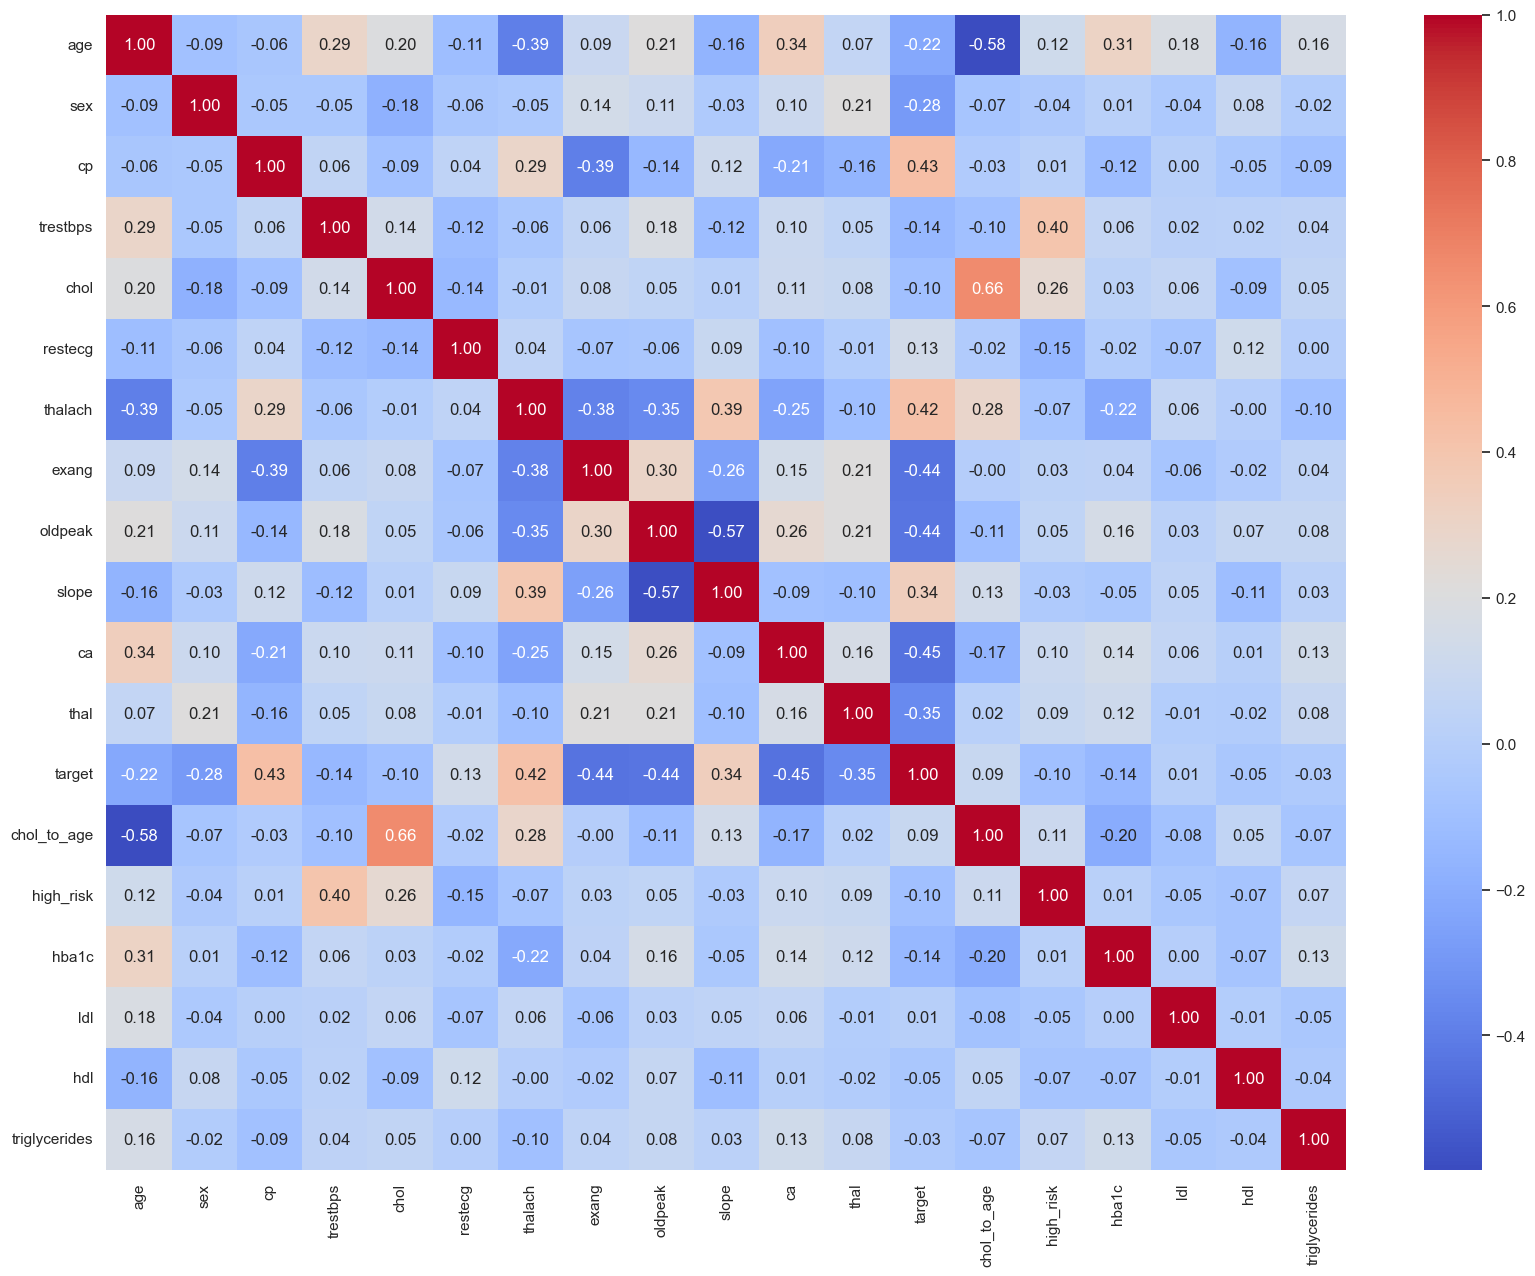

In [58]:
plt.figure(figsize=(20,15))
sns.heatmap(
    data= corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.show()

## Question 34
**If two features have a correlation higher than 0.85:**

**Which one do you remove?Why?**

We remove the feature that holds the least importance in terms of business understanding, exhibits lower variance compared to the other field, and has a higher number of missing values, as it contributes to overfitting.

## Question 35
**Create a reduced version of the dataset.**

In [59]:
removable = [
    "sex", "id", "patient_id", "age_group", "chol_risk", "hba1c",
    "bp_level", "fbs", "high_risk", "restecg", "chol_to_age"
]

reduced_df = merged_dataset.drop(columns=removable)
reduced_df


,age,cp,trestbps,chol,thalach,exang,oldpeak,slope,ca,thal,target,ldl,hdl,triglycerides
0,63,3,145,233.0,150.0,0,2.3,0,0.0,1.0,1,111,47,82
1,37,2,130,250.0,187.0,0,3.5,0,0.0,2.0,1,96,67,153
2,41,1,130,204.0,172.0,0,1.4,2,0.0,2.0,1,85,39,151
3,56,1,120,236.0,178.0,0,0.8,2,0.0,2.0,1,95,32,220
4,57,0,120,354.0,163.0,1,0.6,2,0.0,2.0,1,119,30,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,140,241.0,123.0,1,0.2,1,0.0,3.0,0,101,40,155
298,45,3,110,264.0,132.0,0,1.2,1,0.0,3.0,0,103,47,129
299,68,0,144,193.0,141.0,0,3.4,1,2.0,3.0,0,81,54,141
300,57,0,130,131.0,115.0,1,1.2,1,1.0,3.0,0,111,46,105


## Question 36
**Examine whether the numerical characteristics have different scales.**

For models such as `linear regression`, `SVM`, `PCA`, `logistic regression`, `KNN`, `K-Means`, and `DBSCAN`, numerical scales are crucial; if the values ​​in one column are significantly larger than those in another, the model may incorrectly assume the former is more important, leading to issues during modeling. Therefore, we must adjust the numerical data using techniques like `normalization` and `standardization`.

## Question 37
**For all numerical features:**
**Implement Min-Max Scaling using NumPy.**

In [64]:
scaled_df = reduced_df.copy(deep=True)
removable = ["cp", "slope", "ca", "thal", "target"]

numericals = scaled_df.columns.to_list()
for column in removable:
    numericals.remove(column)



for column in numericals:
    array = scaled_df[column].values   
    minimum = np.min(array)
    maximum = np.max(array)
    try:
        result = (array - minimum) / (maximum - minimum)
        scaled_df[column] = result
    
    except ZeroDivisionError:
        scaled_df[column] = 0
        
scaled_df.head()
    


,age,cp,trestbps,chol,thalach,exang,oldpeak,slope,ca,thal,target,ldl,hdl,triglycerides
0,0.708333,3,0.671053,0.437852,0.558855,0.0,0.575,0,0.0,1.0,1,0.559633,0.414634,0.172043
1,0.166667,2,0.473684,0.507417,0.872747,0.0,0.875,0,0.0,2.0,1,0.422018,0.902439,0.553763
2,0.250000,1,0.473684,0.319182,0.745493,0.0,0.350,2,0.0,2.0,1,0.321101,0.219512,0.543011
3,0.562500,1,0.342105,0.450128,0.796394,0.0,0.200,2,0.0,2.0,1,0.412844,0.048780,0.913978
4,0.583333,0,0.342105,0.932992,0.669141,1.0,0.150,2,0.0,2.0,1,0.633028,0.000000,0.381720


## Question 38
**For all numerical features:**
**Implement standardization using NumPy.**

In [71]:
for column in numericals:
    array = scaled_df[column].values   
    avg = np.mean(array)
    std = np.std(array)
    try:
        result = (array - avg) / std
        scaled_df[column] = result
    
    except ZeroDivisionError:
        scaled_df[column] = 0
    
scaled_df.head()

,age,cp,trestbps,chol,thalach,exang,oldpeak,slope,ca,thal,target,ldl,hdl,triglycerides
0,0.949794,3,0.828927,-0.261076,0.017027,-0.698344,1.147606,0,0.0,1.0,1,0.975414,0.158173,-1.362863
1,-1.928548,2,-0.075902,0.097514,1.644957,-0.698344,2.230096,0,0.0,2.0,1,0.201981,2.248687,0.423572
2,-1.485726,1,-0.075902,-0.872787,0.984985,-0.698344,0.335739,2,0.0,2.0,1,-0.365204,-0.678033,0.373250
3,0.174856,1,-0.679121,-0.197795,1.248974,-0.698344,-0.205506,2,0.0,2.0,1,0.150418,-1.409713,2.109363
4,0.285561,0,-0.679121,2.291236,0.589003,1.431958,-0.385921,2,0.0,2.0,1,1.387912,-1.618764,-0.381582


## Question 39
**Before and after scaling:**
**Plot a histogram.**

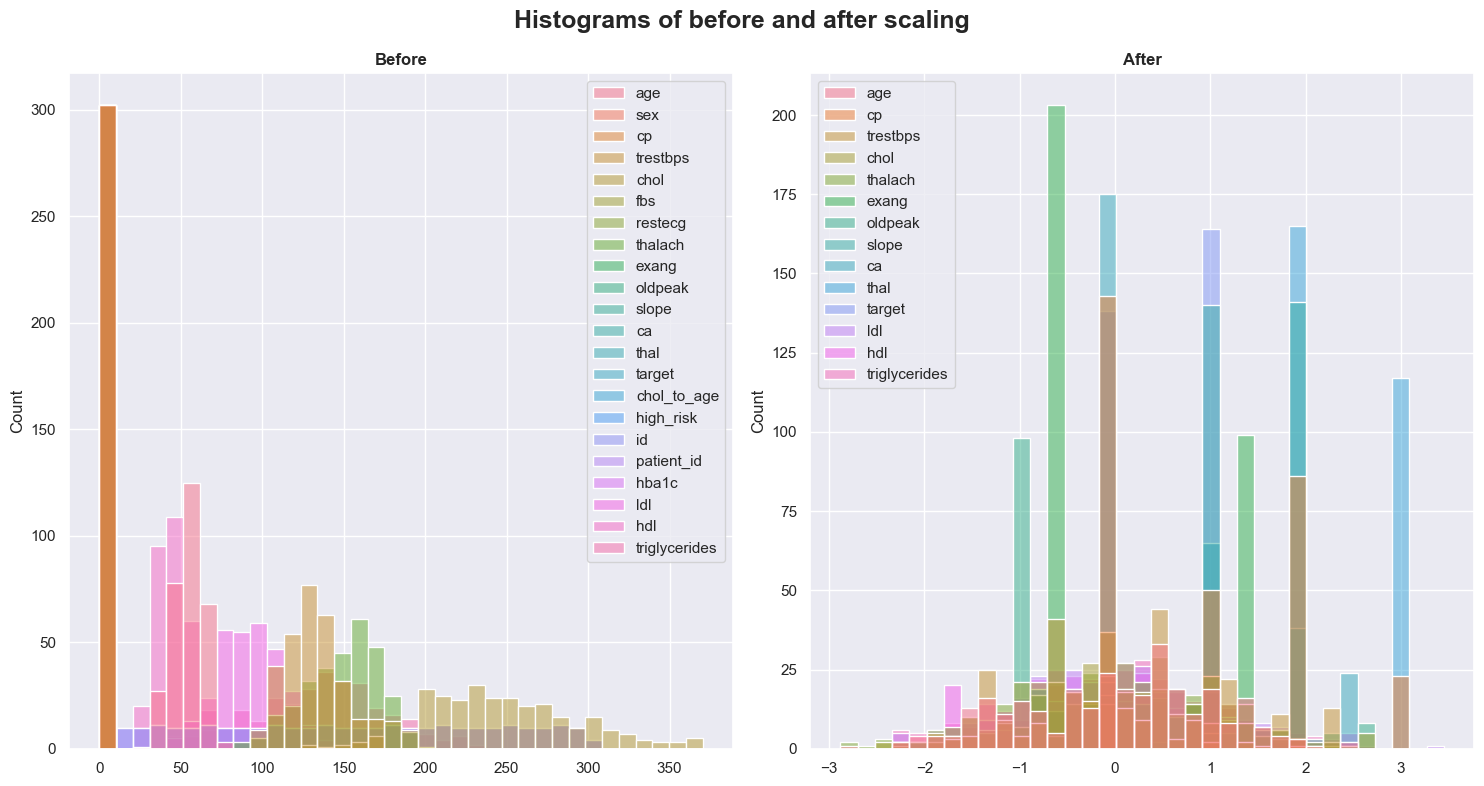

In [79]:
sns.set_theme(style="darkgrid")

fig = plt.figure(figsize=(15, 8))

gs = gridspec.GridSpec(
    1, 2,  
    width_ratios=[1, 1] 
)

fig.suptitle(
    "Histograms of before and after scaling",
    fontsize=18,
    fontweight="bold"
)

ax1 = plt.subplot(gs[0, 0])
sns.histplot(
    data=merged_dataset,
    ax=ax1
)
ax1.set_title("Before", fontweight="bold")
ax1.set_ylabel("Count")


ax2 = plt.subplot(gs[0, 1])
sns.histplot(
    data=scaled_df,
    ax=ax2
)
ax2.set_title("After", fontweight="bold")
ax2.set_ylabel("Count")


plt.tight_layout()
plt.show()

## Question 40
**Compare:**

- **Min-Max Scaling**
- **Standardization**

**Which one is more suitable for this project?**

Everything depends on the model we choose; if the model requires specific ranges, we must use Min-Max scaling to ensure the data falls within a defined range.

However, if there are strange outliers in the data, it is better to use standardization.